# Analisis de Tasas de Cambio - Exchange Rate Analysis

## Objetivo
Realizar un analisis completo de las tasas de cambio que incluya:
- Analisis exploratorio de datos (EDA)
- Pruebas de normalidad
- Pruebas de heteroscedasticidad
- Analisis de multicolinealidad (VIF)
- Modelos de prediccion estadisticos

In [1]:
# Celda 1: Configuracion del entorno y carga de dependencias
import sys
import os

try:
    _notebook_dir = os.path.dirname(__file__)
except NameError:
    _notebook_dir = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(_notebook_dir, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Celda 2: Conexion a la base de datos y carga de datos
import psycopg2

def get_connection():
    db_host = os.getenv("DB_HOST", "postgres")
    
    if db_host == "postgres":
        host = "postgres"
        port = os.getenv("DB_PORT", "5432")
    else:
        host = "localhost"
        port = os.getenv("DB_PORT", "5433")
    
    return psycopg2.connect(
        host=host,
        port=port,
        dbname=os.getenv("DB_NAME", "exchange_db"),
        user=os.getenv("DB_USER", "postgres"),
        password=os.getenv("DB_PASSWORD", "postgres"),
        sslmode="disable"
    )

conn = get_connection()

query = """
SELECT 
    er.id,
    c1.code AS base_currency,
    c2.code AS target_currency,
    er.rate,
    er.timestamp
FROM exchange_rates er
JOIN currencies c1 ON er.base_currency_id = c1.id
JOIN currencies c2 ON er.target_currency_id = c2.id
ORDER BY er.timestamp;
"""

df = pd.read_sql(query, conn)
conn.close()

df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,id,base_currency,target_currency,rate,timestamp
0,1,USD,USD,1.00,2026-04-18 15:49:37.412494+00:00
1,2,USD,AED,3.67,2026-04-18 15:49:37.415097+00:00
2,3,USD,AFN,64.59,2026-04-18 15:49:37.415751+00:00
3,4,USD,ALL,81.24,2026-04-18 15:49:37.416188+00:00
4,5,USD,AMD,374.19,2026-04-18 15:49:37.416522+00:00


## 1. Analisis Exploratorio de Datos (EDA)

ANALISIS EXPLORATORIO DE DATOS (EDA)

Forma del dataset: (332, 5)

Periodo de datos: 2026-04-18 15:49:37.412494+00:00 a 2026-05-10 00:00:01+00:00

Monedas base disponibles: ['USD']
Monedas destino disponibles: 166 monedas

--- Estadisticas descriptivas ---
count    3.320000e+02
mean     8.539372e+03
std      8.986857e+04
min      2.240000e-02
25%      2.879675e+00
50%      2.240485e+01
75%      1.836335e+02
max      1.160586e+06
Name: rate, dtype: float64


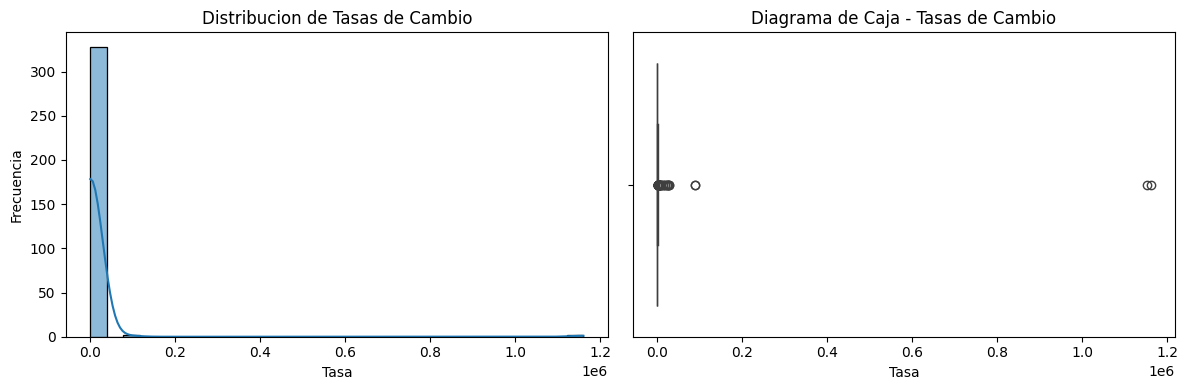

In [3]:
# Celda 3: Analisis exploratorio de datos
print("=" * 60)
print("ANALISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 60)

print(f"\nForma del dataset: {df.shape}")
print(f"\nPeriodo de datos: {df['timestamp'].min()} a {df['timestamp'].max()}")
print(f"\nMonedas base disponibles: {df['base_currency'].unique()}")
print(f"Monedas destino disponibles: {df['target_currency'].nunique()} monedas")

print("\n--- Estadisticas descriptivas ---")
print(df['rate'].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['rate'], kde=True, bins=30)
plt.title('Distribucion de Tasas de Cambio')
plt.xlabel('Tasa')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['rate'])
plt.title('Diagrama de Caja - Tasas de Cambio')
plt.xlabel('Tasa')

plt.tight_layout()
plt.show()

## 2. Pruebas de Normalidad

Las pruebas de normalidad determinan si los datos siguen una distribucion normal.
- **Hipotesis nula (H0)**: Los datos siguen una distribucion normal
- **Hipotesis alternativa (H1)**: Los datos no siguen una distribucion normal
- **Nivel de significancia**: alpha = 0.05

In [ ]:
# Celda 4: Pruebas de Normalidad
print("=" * 60)
print("PRUEBAS DE NORMALIDAD")
print("=" * 60)

rates = df['rate'].dropna()

sample = rates.sample(min(5000, len(rates)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"\n1. Shapiro-Wilk: Estadistico={shapiro_stat:.6f}, p={shapiro_p:.6f}")

jb_stat, jb_p = stats.jarque_bera(rates)
print(f"\n2. Jarque-Bera: Estadistico={jb_stat:.6f}, p={jb_p:.6f}")

dagostino_stat, dagostino_p = stats.normaltest(rates)
print(f"\n3. D'Agostino: Estadistico={dagostino_stat:.6f}, p={dagostino_p:.6f}")

ks_stat, ks_p = stats.kstest(rates, 'norm', args=(rates.mean(), rates.std()))
print(f"\n4. Kolmogorov-Smirnov: Estadistico={ks_stat:.6f}, p={ks_p:.6f}")

## 3. Pruebas de Heteroscedasticidad

La heteroscedasticidad ocurre cuando la varianza de los errores no es constante.

In [ ]:
# Celda 5: Pruebas de Heteroscedasticidad
df_ts = df.copy()
df_ts = df_ts.set_index('timestamp').sort_index()

df_reg = df_ts[['rate']].copy()
df_reg['rate_lag1'] = df_reg['rate'].shift(1)
df_reg['rate_lag2'] = df_reg['rate'].shift(2)
df_reg['rate_lag3'] = df_reg['rate'].shift(3)
df_reg = df_reg.dropna()

X = df_reg[['rate_lag1', 'rate_lag2', 'rate_lag3']]
X = sm.add_constant(X)
y = df_reg['rate']

model = sm.OLS(y, X).fit()
residuals = model.resid

bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X)
white_stat, white_p, white_f, white_fp = het_white(residuals, X)

print("Prueba de Breusch-Pagan: estadistico LM =", round(bp_stat, 4), ", p =", round(bp_p, 6))
print("Prueba de White: estadistico =", round(white_stat, 4), ", p =", round(white_p, 6))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribucion de Residuos')

plt.tight_layout()
plt.show()

## 4. Analisis de Multicolinealidad (VIF)

El Factor de Inflacion de Varianza (VIF) mide la correlacion entre predictores.

In [ ]:
# Celda 6: Analisis de Multicolinealidad (VIF)
X_vif = df_reg[['rate_lag1', 'rate_lag2', 'rate_lag3']]

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data

vif_df = calculate_vif(X_vif)
vif_df

## 5. Modelos de Prediccion

A continuacion se construyen modelos estadisticos para predecir tasas de cambio.

In [ ]:
# Celda 7: Modelo de Regresion Lineal OLS
model_ols = sm.OLS(y, X).fit()
model_ols.summary()

In [ ]:
# Celda 8: Modelo ARIMA
sample_currency = 'EUR'
df_eur = df[df['target_currency'] == sample_currency].copy()
df_eur = df_eur.set_index('timestamp').sort_index()

eur_rates = df_eur['rate'].dropna()
if len(eur_rates) < 20:
    print(f"Datos insuficientes para {sample_currency}. Solo hay {len(eur_rates)} registros.")
else:
    adf_result = adfuller(eur_rates)

    print("Prueba de Dickey-Fuller para EUR:")
    print("Estadistico ADF:", round(adf_result[0], 4))
    print("Valor p:", round(adf_result[1], 6))

    model_arima = ARIMA(eur_rates, order=(1, 1, 1))
    model_arima_fit = model_arima.fit()
    print("\nModelo ARIMA(1,1,1) - AIC:", round(model_arima_fit.aic, 2))
    print("Modelo ARIMA(1,1,1) - BIC:", round(model_arima_fit.bic, 2))
    model_arima_fit.params

In [ ]:
# Celda 9: Predicciones ARIMA
try:
    forecast = model_arima_fit.forecast(steps=10)
    forecast
except NameError:
    print("No hay modelo ARIMA disponible (datos insuficientes en celda anterior)")

In [ ]:
# Celda 10: Modelo de Regresion con Variables Categoricas
df_model = df.copy()
df_model['rate_lag1'] = df_model.groupby('target_currency')['rate'].shift(1)
df_model = df_model.dropna()

top_currencies = df_model['target_currency'].value_counts().head(10).index.tolist()
df_model = df_model[df_model['target_currency'].isin(top_currencies)]

df_dummies = pd.get_dummies(df_model['target_currency'], prefix='currency', drop_first=True, dtype=int)
X_multi = pd.concat([df_model[['rate_lag1']], df_dummies], axis=1)
X_multi = sm.add_constant(X_multi)
y_multi = df_model['rate']

model_multi = sm.OLS(y_multi, X_multi).fit()
model_multi.summary()

## 6. Conclusiones y Recomendaciones

In [ ]:
# Celda 11: Resumen de Resultados
resultados = pd.DataFrame({
    'Prueba': ['Shapiro-Wilk', 'Jarque-Bera', 'D\'Agostino', 'Kolmogorov-Smirnov', 'Breusch-Pagan', 'White'],
    'Estadistico': [shapiro_stat, jb_stat, dagostino_stat, ks_stat, bp_stat, white_stat],
    'Valor p': [shapiro_p, jb_p, dagostino_p, ks_p, bp_p, white_p],
    'Conclusion': [
        'No Normal' if shapiro_p < 0.05 else 'Normal',
        'No Normal' if jb_p < 0.05 else 'Normal',
        'No Normal' if dagostino_p < 0.05 else 'Normal',
        'No Normal' if ks_p < 0.05 else 'Normal',
        'Heteroscedasticidad' if bp_p < 0.05 else 'Homoscedasticidad',
        'Heteroscedasticidad' if white_p < 0.05 else 'Homoscedasticidad'
    ]
})
resultados

In [ ]:
# Celda 12: Guardar resultados en la base de datos
conn = get_connection()
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS exchange_rate_predictions (
    id SERIAL PRIMARY KEY,
    target_currency VARCHAR(10) NOT NULL,
    prediction_date TIMESTAMP NOT NULL,
    predicted_rate NUMERIC(20,10),
    model_type VARCHAR(50),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS exchange_rate_clusters (
    id SERIAL PRIMARY KEY,
    target_currency VARCHAR(10) NOT NULL,
    avg_rate NUMERIC(20,10),
    volatility NUMERIC(20,10),
    cluster INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()
cursor.close()
conn.close()

print("Tablas creadas: exchange_rate_predictions, exchange_rate_clusters")